# Dermatology benchmark dataset explorer

Use this notebook to inspect the Parquet datasets under `data/benchmarks/`. It provides:

- an inventory of every benchmark Parquet file;
- table previews, schemas, and missing-value summaries;
- disease and source distributions;
- evidence-grounded cohort and morphology summaries;
- image previews, including images stored inside ZIP archives.

The notebook is read-only unless you explicitly run the optional CSV export cell.

## 1. Setup

The following cell finds the repository root automatically, whether Jupyter was launched from the repository root or from `src/`.

In [1]:
from __future__ import annotations

from collections import Counter
from io import BytesIO
from pathlib import Path
import sys

import pandas as pd
import pyarrow.parquet as pq
from PIL import Image
from IPython.display import display


def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "configs").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root")


ROOT = find_repository_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_pipeline.deduplication import ImageResolver

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

print(f"Repository root: {ROOT}")

Repository root: /Users/danielfd98/Code/ISEP


## 2. Discover benchmark datasets

This scans `data/benchmarks/` recursively, so newly generated benchmark Parquets will appear automatically.

In [2]:
BENCHMARK_ROOT = ROOT / "data/benchmarks"
PARQUET_CATALOG = {
    str(path.relative_to(BENCHMARK_ROOT)): path
    for path in sorted(BENCHMARK_ROOT.rglob("*.parquet"))
}

if not PARQUET_CATALOG:
    raise FileNotFoundError(f"No Parquet files found under {BENCHMARK_ROOT}")

print(f"Found {len(PARQUET_CATALOG)} benchmark Parquet files")
for name in PARQUET_CATALOG:
    print(f"- {name}")

Found 9 benchmark Parquet files
- evidence_grounded_diagnosis_v1/datasets/external/evidence_grounded_ddi.parquet
- visual_confusion_sets_v1/datasets/internal/confusion_tasks.parquet
- visual_top_k_v1/datasets/external/external_ddi.parquet
- visual_top_k_v1/datasets/external/external_skindisnet.parquet
- visual_top_k_v1/datasets/internal/internal_benchmark_1000.parquet
- visual_top_k_v1/datasets/internal/internal_test.parquet
- visual_top_k_v1/datasets/internal/internal_test_reserve.parquet
- visual_top_k_v1/datasets/internal/train.parquet
- visual_top_k_v1/datasets/internal/validation.parquet


In [3]:
def summarize_parquet(name: str, path: Path) -> dict[str, object]:
    parquet = pq.ParquetFile(path)
    columns = parquet.schema_arrow.names
    useful_columns = [
        column
        for column in [
            "dataset_id",
            "disease_id",
            "leakage_group_id",
            "group_id",
            "score_morphology",
            "score_description",
            "score_diagnosis",
        ]
        if column in columns
    ]
    frame = (
        pd.read_parquet(path, columns=useful_columns)
        if useful_columns
        else pd.DataFrame()
    )
    group_column = next(
        (column for column in ["leakage_group_id", "group_id"] if column in frame),
        None,
    )
    return {
        "dataset": name,
        "rows": parquet.metadata.num_rows,
        "columns": parquet.metadata.num_columns,
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3),
        "sources": frame["dataset_id"].nunique() if "dataset_id" in frame else pd.NA,
        "groups": frame[group_column].nunique() if group_column else pd.NA,
        "disease_classes": frame["disease_id"].nunique() if "disease_id" in frame else pd.NA,
        "morphology_cases": int(frame["score_morphology"].sum()) if "score_morphology" in frame else pd.NA,
        "description_cases": int(frame["score_description"].sum()) if "score_description" in frame else pd.NA,
        "diagnosis_cases": int(frame["score_diagnosis"].sum()) if "score_diagnosis" in frame else pd.NA,
    }


inventory = pd.DataFrame(
    summarize_parquet(name, path)
    for name, path in PARQUET_CATALOG.items()
).sort_values("dataset", ignore_index=True)

display(inventory)

,dataset,rows,columns,size_mb,sources,groups,disease_classes,morphology_cases,description_cases,diagnosis_cases
0,evidence_grounded_diagnosis_v1/datasets/external/evidence_grounded_ddi.parquet,636,16,0.073,1,632,8,636,635,294
1,visual_confusion_sets_v1/datasets/internal/confusion_tasks.parquet,828,12,0.040,3,414,15,<NA>,<NA>,<NA>
2,visual_top_k_v1/datasets/external/external_ddi.parquet,300,49,0.048,1,299,8,<NA>,<NA>,<NA>
3,visual_top_k_v1/datasets/external/external_skindisnet.parquet,1365,49,0.127,1,333,4,<NA>,<NA>,<NA>
4,visual_top_k_v1/datasets/internal/internal_benchmark_1000.parquet,1000,49,0.193,3,1000,21,<NA>,<NA>,<NA>
5,visual_top_k_v1/datasets/internal/internal_test.parquet,1722,49,0.265,3,1063,21,<NA>,<NA>,<NA>
6,visual_top_k_v1/datasets/internal/internal_test_reserve.parquet,63,49,0.045,3,63,21,<NA>,<NA>,<NA>
7,visual_top_k_v1/datasets/internal/train.parquet,6417,49,0.923,3,4962,21,<NA>,<NA>,<NA>
8,visual_top_k_v1/datasets/internal/validation.parquet,1683,49,0.262,3,1063,21,<NA>,<NA>,<NA>


## 3. Select and load a dataset

Change `DATASET_NAME` to any value shown in the inventory above, then rerun this cell and the cells below it.

In [4]:
# Examples:
# visual_top_k_v1/datasets/internal/internal_benchmark_1000.parquet
# visual_top_k_v1/datasets/external/external_ddi.parquet
# evidence_grounded_diagnosis_v1/datasets/external/evidence_grounded_ddi.parquet
# visual_confusion_sets_v1/datasets/internal/confusion_tasks.parquet

preferred = "visual_top_k_v1/datasets/internal/internal_benchmark_1000.parquet"
DATASET_NAME = preferred if preferred in PARQUET_CATALOG else next(iter(PARQUET_CATALOG))

DATASET_PATH = PARQUET_CATALOG[DATASET_NAME]
df = pd.read_parquet(DATASET_PATH)

print(f"Loaded: {DATASET_NAME}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head(10))

Loaded: visual_top_k_v1/datasets/internal/internal_benchmark_1000.parquet
Shape: 1,000 rows × 43 columns


,schema_version,sample_id,dataset_id,dataset_version,original_image_id,original_case_id,patient_id,group_id,image_uri,disease_original,canonical_source_label,disease_id,reference_diagnoses,mapping_status,diagnosis_basis,diagnosis_gradable,taxonomy_id,taxonomy_version,age_years,age_group_source,age_group_standardized,age_source,sex_or_gender,sex_or_gender_system,sex_or_gender_source,race_ethnicity,race_ethnicity_source,skin_tone_system,skin_tone,skin_tone_source,image_sha256,perceptual_hash,perceptual_hash_algorithm,duplicate_group_id,duplicate_match_type,deduplication_status,leakage_group_id,license_id,split,split_version,include,exclusion_reason,source_metadata
0,1.3.0,FITZPATRICK17K_C_00f1b7bb9581e91250a2bb224c3321b8,fitzpatrick17k_c,corrected_2024_release,00f1b7bb9581e91250a2bb224c3321b8,NaN,NaN,FITZPATRICK17K_C_IMAGE_00f1b7bb9581e91250a2bb224c3321b8,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/00f1b7bb9581e91250a2bb224c3321b...,melanoma,melanoma,D001,"[{'disease_original': 'melanoma', 'disease_id': 'D001', 'canonical_source_label': 'melanoma', 'mapping_status': 'ben...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_4,expert_or_crowd_annotated,ec1e93444efc9f97439c32194958276fe4e277f80e53b4cc31f47ebde4ee1ffe,e34a6771643732b2,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_00f1b7bb9581e91250a2bb224c3321b8,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/00f1b7bb9581e91250a2bb224c3321b8.jpg"", ""diag"": ""me"", ""nine_partition_label"": ""..."
1,1.3.0,FITZPATRICK17K_C_01ea9b82a2e0a7b5eec83dc46e636e03,fitzpatrick17k_c,corrected_2024_release,01ea9b82a2e0a7b5eec83dc46e636e03,NaN,NaN,FITZPATRICK17K_C_IMAGE_01ea9b82a2e0a7b5eec83dc46e636e03,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/01ea9b82a2e0a7b5eec83dc46e636e0...,allergic contact dermatitis,contact_dermatitis,D009,"[{'disease_original': 'allergic contact dermatitis', 'disease_id': 'D009', 'canonical_source_label': 'contact_dermat...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_1,expert_or_crowd_annotated,8cdae3c95294160c8f18f0ff3199564573a0353e4f662101137a1703d619b4de,e008550d7d9e736e,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_01ea9b82a2e0a7b5eec83dc46e636e03,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/01ea9b82a2e0a7b5eec83dc46e636e03.jpg"", ""diag"": ""al-co-de"", ""nine_partition_lab..."
2,1.3.0,FITZPATRICK17K_C_04196e1bcea2137a53790a42b56f0c12,fitzpatrick17k_c,corrected_2024_release,04196e1bcea2137a53790a42b56f0c12,NaN,NaN,FITZPATRICK17K_C_IMAGE_04196e1bcea2137a53790a42b56f0c12,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/04196e1bcea2137a53790a42b56f0c1...,granuloma annulare,granuloma_annulare,D023,"[{'disease_original': 'granuloma annulare', 'disease_id': 'D023', 'canonical_source_label': 'granuloma_annulare', 'm...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_1,expert_or_crowd_annotated,5b1d3a00e59464b1e3f68bdfbc00cd470bc350400ef31c5f451bb82a898411fd,868c39e4628ddbb9,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_04196e1bcea2137a53790a42b56f0c12,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/04196e1bcea2137a53790a42b56f0c12.jpg"", ""diag"": ""gr-an"", ""nine_partition_label""..."
3,1.3.0,FITZPATRICK17K_C_053a5ee87f2fc71f07e99a25fd379210,fitzpatrick17k_c,corrected_2024_release,053a5ee87f2fc71f07e99a25fd379210,NaN,NaN,FITZPATRICK17K_C_IMAGE_053a5ee87f2fc71f07e99a25fd379210,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/053a5ee87f2fc71f07e99a25fd37921...,basal cell carcinoma,basal_cell_carcinoma,D

## 4. Schema and missing values

In [5]:
schema_summary = pd.DataFrame(
    {
        "column": df.columns,
        "pandas_dtype": [str(df[column].dtype) for column in df.columns],
        "non_null": [int(df[column].notna().sum()) for column in df.columns],
        "missing": [int(df[column].isna().sum()) for column in df.columns],
        "missing_percent": [round(float(df[column].isna().mean() * 100), 2) for column in df.columns],
    }
)

display(schema_summary)

,column,pandas_dtype,non_null,missing,missing_percent
0,schema_version,str,1000,0,0.0
1,sample_id,str,1000,0,0.0
2,dataset_id,str,1000,0,0.0
3,dataset_version,str,1000,0,0.0
4,original_image_id,str,1000,0,0.0
5,original_case_id,str,455,545,54.5
6,patient_id,str,142,858,85.8
7,group_id,str,1000,0,0.0
8,image_uri,str,1000,0,0.0
9,disease_original,str,1000,0,0.0


In [ ]:
print(pq.ParquetFile(DATASET_PATH).schema_arrow)

## 5. Disease, source, and split distributions

Only summaries supported by the selected dataset are displayed.

In [6]:
for column in ["dataset_id", "split", "disease_id", "skin_tone", "difficulty", "confusion_set_id"]:
    if column not in df.columns:
        continue
    print(f"\n{column}")
    counts = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="count")
    )
    counts["percent"] = (counts["count"] / len(df) * 100).round(2)
    display(counts)



dataset_id


,dataset_id,count,percent
0,fitzpatrick17k_c,545,54.5
1,scin,313,31.3
2,pad_ufes_20,142,14.2



split


,split,count,percent
0,internal_benchmark_1000,1000,100.0



disease_id


,disease_id,count,percent
0,D014,129,12.9
1,D009,113,11.3
2,D004,111,11.1
3,D011,73,7.3
4,D005,71,7.1
5,D017,65,6.5
6,D016,54,5.4
7,D007,53,5.3
8,D001,45,4.5
9,D025,34,3.4



skin_tone


,skin_tone,count,percent
0,FST_2,212,21.2
1,FST_3,113,11.3
2,FST_4,101,10.1
3,FST_1,100,10.0
4,MST_3,84,8.4
5,MST_2,83,8.3
6,FST_5,74,7.4
7,NaN,45,4.5
8,MST_4,44,4.4
9,FST_6,42,4.2


## 6. Evidence-grounded dataset summaries

These cells become active when the selected dataset contains evidence-grounded scoring flags or morphology concepts.

In [7]:
score_columns = [
    column
    for column in ["score_morphology", "score_description", "score_diagnosis"]
    if column in df.columns
]

if score_columns:
    cohort_summary = pd.DataFrame(
        {
            "cohort": score_columns,
            "sample_count": [int(df[column].sum()) for column in score_columns],
            "percent": [round(float(df[column].mean() * 100), 2) for column in score_columns],
        }
    )
    display(cohort_summary)
else:
    print("The selected dataset has no evidence-grounded scoring flags.")

The selected dataset has no evidence-grounded scoring flags.


In [8]:
if "morphology_concept_ids" in df.columns:
    morphology_counts = (
        df["morphology_concept_ids"]
        .explode()
        .dropna()
        .value_counts()
        .rename_axis("concept_id")
        .reset_index(name="positive_images")
    )
    morphology_counts["percent_of_images"] = (
        morphology_counts["positive_images"] / len(df) * 100
    ).round(2)
    display(morphology_counts)
else:
    print("The selected dataset has no morphology reference column.")

The selected dataset has no morphology reference column.


## 7. View image samples

`ImageResolver` supports both ordinary paths and `zip://archive.zip::member.jpg` URIs. Errors are shown inline when an image is unavailable.

,value
sample_id,FITZPATRICK17K_C_f4691ed2d1bddd01e929272db72e22c4
dataset_id,fitzpatrick17k_c
disease_id,D007
disease_original,actinic keratosis
skin_tone,FST_1


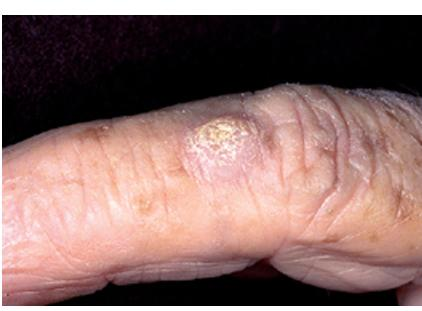

----------------------------------------------------------------------------------------------------


,value
sample_id,SCIN_-3768594983498155183_IMAGE_1
dataset_id,scin
disease_id,D017
disease_original,Urticaria
skin_tone,MST_4


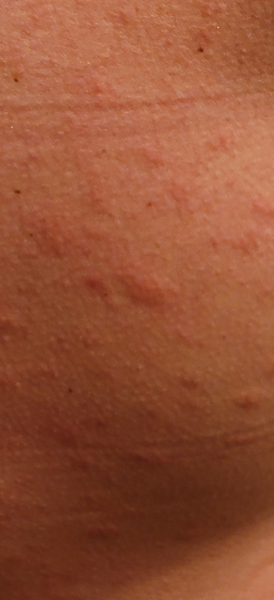

----------------------------------------------------------------------------------------------------


,value
sample_id,SCIN_-4032921157387474723_IMAGE_1
dataset_id,scin
disease_id,D009
disease_original,Allergic Contact Dermatitis
skin_tone,MST_1


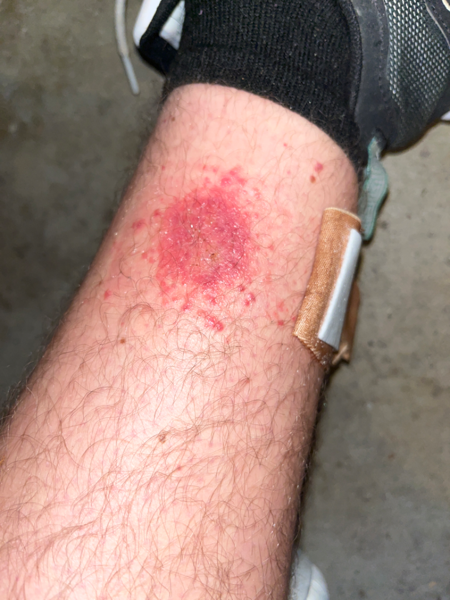

----------------------------------------------------------------------------------------------------


,value
sample_id,PAD_UFES_20_PAT_766_1670_458
dataset_id,pad_ufes_20
disease_id,D007
disease_original,ACK
skin_tone,FST_3


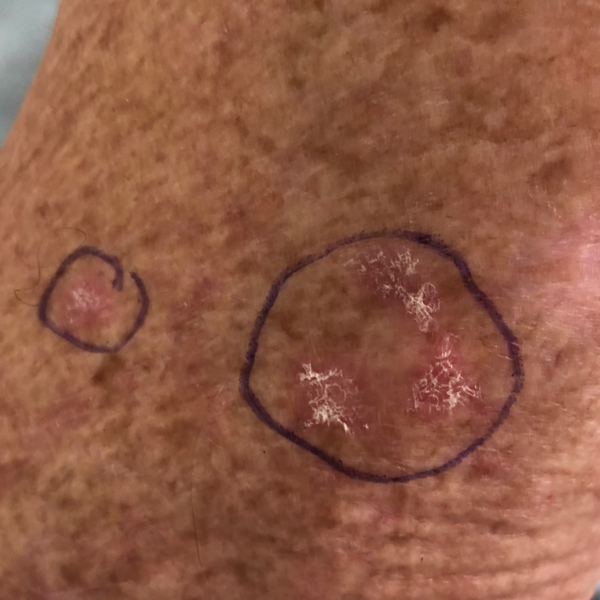

----------------------------------------------------------------------------------------------------


,value
sample_id,FITZPATRICK17K_C_bb669c6222879253ff4d274a083c4fbe
dataset_id,fitzpatrick17k_c
disease_id,D016
disease_original,folliculitis
skin_tone,FST_6


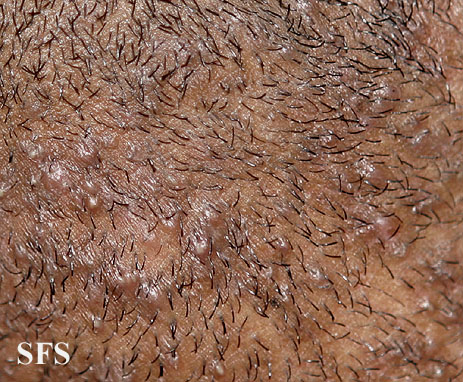

----------------------------------------------------------------------------------------------------


In [9]:
def show_image_samples(
    frame: pd.DataFrame,
    *,
    count: int = 5,
    random_state: int = 42,
    max_size: tuple[int, int] = (600, 600),
) -> None:
    if "image_uri" not in frame.columns:
        print("The selected dataset has no image_uri column.")
        return
    count = min(count, len(frame))
    samples = frame.sample(n=count, random_state=random_state)
    metadata_columns = [
        column
        for column in [
            "sample_id",
            "task_id",
            "dataset_id",
            "disease_id",
            "disease_original",
            "skin_tone",
            "morphology_concept_ids",
            "score_description",
            "score_diagnosis",
        ]
        if column in frame.columns
    ]

    with ImageResolver(ROOT) as resolver:
        for _, row in samples.iterrows():
            display(row[metadata_columns].to_frame(name="value"))
            try:
                image_bytes = resolver.read_bytes(str(row["image_uri"]))
                image = Image.open(BytesIO(image_bytes)).convert("RGB")
                image.thumbnail(max_size)
                display(image)
            except Exception as exc:
                print(f"Could not load {row['image_uri']}: {exc}")
            print("-" * 100)


show_image_samples(df, count=5, random_state=42)

## 8. Filter examples

Use normal pandas expressions to create a smaller view without modifying the source Parquet.

In [10]:
# Example: select only diagnosis-scored evidence-grounded cases.
if "score_diagnosis" in df.columns:
    filtered_df = df[df["score_diagnosis"]].copy()
elif "disease_id" in df.columns:
    filtered_df = df[df["disease_id"].notna()].copy()
else:
    filtered_df = df.copy()

print(f"Filtered rows: {len(filtered_df):,}")
display(filtered_df.head(10))

Filtered rows: 1,000


,schema_version,sample_id,dataset_id,dataset_version,original_image_id,original_case_id,patient_id,group_id,image_uri,disease_original,canonical_source_label,disease_id,reference_diagnoses,mapping_status,diagnosis_basis,diagnosis_gradable,taxonomy_id,taxonomy_version,age_years,age_group_source,age_group_standardized,age_source,sex_or_gender,sex_or_gender_system,sex_or_gender_source,race_ethnicity,race_ethnicity_source,skin_tone_system,skin_tone,skin_tone_source,image_sha256,perceptual_hash,perceptual_hash_algorithm,duplicate_group_id,duplicate_match_type,deduplication_status,leakage_group_id,license_id,split,split_version,include,exclusion_reason,source_metadata
0,1.3.0,FITZPATRICK17K_C_00f1b7bb9581e91250a2bb224c3321b8,fitzpatrick17k_c,corrected_2024_release,00f1b7bb9581e91250a2bb224c3321b8,NaN,NaN,FITZPATRICK17K_C_IMAGE_00f1b7bb9581e91250a2bb224c3321b8,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/00f1b7bb9581e91250a2bb224c3321b...,melanoma,melanoma,D001,"[{'disease_original': 'melanoma', 'disease_id': 'D001', 'canonical_source_label': 'melanoma', 'mapping_status': 'ben...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_4,expert_or_crowd_annotated,ec1e93444efc9f97439c32194958276fe4e277f80e53b4cc31f47ebde4ee1ffe,e34a6771643732b2,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_00f1b7bb9581e91250a2bb224c3321b8,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/00f1b7bb9581e91250a2bb224c3321b8.jpg"", ""diag"": ""me"", ""nine_partition_label"": ""..."
1,1.3.0,FITZPATRICK17K_C_01ea9b82a2e0a7b5eec83dc46e636e03,fitzpatrick17k_c,corrected_2024_release,01ea9b82a2e0a7b5eec83dc46e636e03,NaN,NaN,FITZPATRICK17K_C_IMAGE_01ea9b82a2e0a7b5eec83dc46e636e03,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/01ea9b82a2e0a7b5eec83dc46e636e0...,allergic contact dermatitis,contact_dermatitis,D009,"[{'disease_original': 'allergic contact dermatitis', 'disease_id': 'D009', 'canonical_source_label': 'contact_dermat...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_1,expert_or_crowd_annotated,8cdae3c95294160c8f18f0ff3199564573a0353e4f662101137a1703d619b4de,e008550d7d9e736e,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_01ea9b82a2e0a7b5eec83dc46e636e03,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/01ea9b82a2e0a7b5eec83dc46e636e03.jpg"", ""diag"": ""al-co-de"", ""nine_partition_lab..."
2,1.3.0,FITZPATRICK17K_C_04196e1bcea2137a53790a42b56f0c12,fitzpatrick17k_c,corrected_2024_release,04196e1bcea2137a53790a42b56f0c12,NaN,NaN,FITZPATRICK17K_C_IMAGE_04196e1bcea2137a53790a42b56f0c12,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/04196e1bcea2137a53790a42b56f0c1...,granuloma annulare,granuloma_annulare,D023,"[{'disease_original': 'granuloma annulare', 'disease_id': 'D023', 'canonical_source_label': 'granuloma_annulare', 'm...",benchmark_mapped,atlas_label,True,dermatology_diseases,2.2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fitzpatrick,FST_1,expert_or_crowd_annotated,5b1d3a00e59464b1e3f68bdfbc00cd470bc350400ef31c5f451bb82a898411fd,868c39e4628ddbb9,phash_dct_32x32_low8x8_median_v1,NaN,NaN,unique,FITZPATRICK17K_C_IMAGE_04196e1bcea2137a53790a42b56f0c12,CC_BY_NC_SA_3_0,internal_benchmark_1000,1.0.1,True,NaN,"{""archive_member"": ""data/finalfitz17k/04196e1bcea2137a53790a42b56f0c12.jpg"", ""diag"": ""gr-an"", ""nine_partition_label""..."
3,1.3.0,FITZPATRICK17K_C_053a5ee87f2fc71f07e99a25fd379210,fitzpatrick17k_c,corrected_2024_release,053a5ee87f2fc71f07e99a25fd379210,NaN,NaN,FITZPATRICK17K_C_IMAGE_053a5ee87f2fc71f07e99a25fd379210,zip://configs/datasets/fitzpatrick17k/data/raw/fitzpatrick17k.zip::data/finalfitz17k/053a5ee87f2fc71f07e99a25fd37921...,basal cell carcinoma,basal_cell_carcinoma,D

## 9. Optional CSV export

Parquet remains the canonical format. CSV is useful for manual inspection in Excel or Numbers, but nested values such as morphology and candidate lists are converted to text. Uncomment the final line to export the current filtered table.

In [ ]:
EXPORT_PATH = ROOT / "outputs/dataset_explorer/filtered_dataset.csv"

# EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
# filtered_df.to_csv(EXPORT_PATH, index=False)
# print(f"Exported to: {EXPORT_PATH}")